# Merger Classification using Vision-TransFormer

- Requirements: `numpy seaborn torch torchvision tensorboard torchmetrics matplotlib pytorch-lightning`
- 

## Hand-made Packages

In [1]:
#%load_ext autoreload
#%autoreload 2
import os, sys
import time
#sys.path.insert(0, '../lib_vistf_hong_v1')
#import lib_vistf_hong_v1 as mylib

**%load_ext autoreload**
- It loads the autoreload extension, which allows you to automatically reload modules before executing code.
- Useful during development, so changes to your module are picked up without restarting the kernel.

**%autoreload 2**
- Enables automatic reloading of all imported modules every time a cell is run.
- `2` means: reload all modules (except those excluded by IPython).
- Helpful when you're editing your custom library in parallel — no need to restart the kernel.

## Basic Packages

In [2]:
import math
import pandas as pd
import numpy  as np
import pickle
from joblib import dump, load
from tqdm import tqdm
import glob

In [3]:
import os
import urllib.request
from urllib.error import HTTPError

import matplotlib
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
import pytorch_lightning as pl
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from torchvision import transforms
from torchvision.datasets import CIFAR10

In [4]:
# Basic Settings for matplotlib
matplotlib.rcParams["font.family"] = "serif"
matplotlib.rcParams["mathtext.fontset"] = "stix"
plt.set_cmap("cividis")
%matplotlib inline
matplotlib_inline.backend_inline.set_matplotlib_formats("svg", "pdf")  # For export
matplotlib.rcParams["lines.linewidth"] = 2.0
sns.reset_orig()

<Figure size 640x480 with 0 Axes>

In [5]:
%load_ext tensorboard
# I will not use tensorboard .. though..

In [6]:
# Setting the seed
pl.seed_everything(42)

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Seed set to 42


In [7]:
# Get cpu, gpu or mps device for training.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [8]:
!nvidia-smi -L

GPU 0: NVIDIA GeForce RTX 3090 (UUID: GPU-24449304-a305-dbe0-a5c8-bc765274bece)
GPU 1: NVIDIA GeForce RTX 3090 (UUID: GPU-1761614d-0d31-5a98-6d73-e9cabf8b877a)


### Data and CheckPoint Directories

In [9]:
pwdir = %pwd
print(pwdir)

/app/vistf/merger-clf/notebook


In [10]:
ROOT_DIR = '/app/vistf/merger-clf/'

In [11]:
# Path to the folder where the datasets are/should be downloaded (e.g. CIFAR10)
DATASET_PATH = ROOT_DIR+'data/'
# Path to the folder where the pretrained models are saved
CHECKPOINT_ROOT = ROOT_DIR+'checkpoints/'

In [12]:
print(DATASET_PATH)
print(CHECKPOINT_ROOT)

/app/vistf/merger-clf/data/
/app/vistf/merger-clf/checkpoints/


#### Checkpoints for each training

In [13]:
from time import gmtime, strftime

base_name = 'merger-clf-'
#try_name = strftime('%Y.%m.%d_%H:%M', gmtime())
try_name = 'take1'
experiment_name = f"{base_name}{try_name}"
print("experiment:", experiment_name)

experiment: merger-clf-take1


In [14]:
import os
import shutil

CHECKPOINT_PATH = os.path.join(CHECKPOINT_ROOT, experiment_name)

if os.path.exists(CHECKPOINT_PATH):
    print(f"⚠️ Directory exists: {CHECKPOINT_PATH}")
    print("🧹 Removing all contents...")

    # Clear all files/subfolders inside the directory
    for filename in os.listdir(CHECKPOINT_PATH):
        file_path = os.path.join(CHECKPOINT_PATH, filename)
        try:
            if os.path.isfile(file_path) or os.path.islink(file_path):
                os.unlink(file_path)
            elif os.path.isdir(file_path):
                shutil.rmtree(file_path)
        except Exception as e:
            print(f"❌ Failed to delete {file_path}: {e}")

    print("✅ Directory has been cleared.")
else:
    os.makedirs(CHECKPOINT_PATH)
    print(f"✅ Directory created: {CHECKPOINT_PATH}")

print(f"📂 Experiment directory is ready: {os.path.abspath(CHECKPOINT_PATH)}")


⚠️ Directory exists: /app/vistf/merger-clf/checkpoints/merger-clf-take1
🧹 Removing all contents...
✅ Directory has been cleared.
📂 Experiment directory is ready: /app/vistf/merger-clf/checkpoints/merger-clf-take1


## Hyperparameters

In [15]:
myINPUT_SHAPE = (500, 500, 1)
myNUM_CLASSES = 3
myBATCH_SIZE = 64
myBUFFER_SIZE = myBATCH_SIZE * 2
myEPOCHS = 100
myIMLEN = 500

## Read, Explore and Load Data

In [16]:
%ls -lh {DATASET_PATH}

total 17G
-rw-rw-r-- 1 1000 1000 3.0G Apr 17 05:51 1000data.pkl
-rw-rw-r-- 1 1000 1000 756M Apr 17 05:53 500data.pkl
-rw-rw-r-- 1 1000 1000 6.4G Apr 17 05:53 500data_noiseX_nside2.pkl
-rw-rw-r-- 1 1000 1000 6.4G Apr 17 05:52 500data_noise_nside2.pkl


In [17]:
%%time
import pickle

with open(DATASET_PATH+'500data_noiseX_nside2.pkl', "rb") as f:
    data = pickle.load(f)

CPU times: user 3.7 ms, sys: 2.66 s, total: 2.67 s
Wall time: 2.67 s


In [18]:
for eachdata in data:
    print('shape: '+str(eachdata.shape))
    print('dtype: '+str(eachdata.dtype))

shape: (2172,)
dtype: <U32
shape: (2172, 500, 500)
dtype: float64
shape: (2172,)
dtype: float64
shape: (544,)
dtype: <U32
shape: (544, 500, 500)
dtype: float64
shape: (544,)
dtype: float64
shape: (680,)
dtype: <U32
shape: (680, 500, 500)
dtype: float64
shape: (680,)
dtype: float64


In [25]:
%%time
x_train = data[1].copy()
y_train = data[2].copy().astype(np.uint8)
x_val = data[4].copy()
y_val = data[5].copy().astype(np.uint8)
x_test = data[7].copy()
y_test = data[8].copy().astype(np.uint8)

CPU times: user 441 ms, sys: 377 ms, total: 818 ms
Wall time: 816 ms


#### Briefly shuffle the train set

In [26]:
import random

numtrain = x_train.shape[0]
print(numtrain)

randidx = list(range(numtrain))
random.shuffle(randidx)
random.shuffle(randidx)
random.shuffle(randidx)

2172


In [27]:
x_train = x_train[randidx]
y_train = y_train[randidx]

In [28]:
numtest = x_test.shape[0]
print(numtest)

randidx = list(range(numtest))
random.shuffle(randidx)
random.shuffle(randidx)
random.shuffle(randidx)

680


In [29]:
y_test[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=uint8)

In [30]:
x_test = x_test[randidx]
y_test = y_test[randidx]

In [31]:
y_test[:10]

array([0, 0, 1, 2, 1, 1, 0, 2, 0, 1], dtype=uint8)

### Mask and Normalize Images 

#### Masking: `inf` = Max Value

In [32]:
ivalid = ~np.isnan(x_test) & ~np.isinf(x_test)
maxvalue = np.max(x_test[ivalid])
minvalue = np.min(x_test[ivalid])
medvalue = np.median(x_test[ivalid])
lowqvalue = np.percentile(x_test[ivalid],25)
highqvalue = np.percentile(x_test[ivalid],75)
maxvalue = np.ceil(maxvalue)
print([medvalue,lowqvalue,highqvalue,minvalue,maxvalue])

[32.00109373129973, 29.81272271309141, 34.39861269372098, 16.35107886967143, 53.0]


In [33]:
x_test[np.isinf(x_test)]=maxvalue
x_val[np.isinf(x_val)]=maxvalue
x_train[np.isinf(x_train)]=maxvalue

#### Optional Masking: Median Cuts

In [34]:
x_test[x_test > medvalue]= medvalue
x_val[x_val > medvalue]= medvalue
x_train[x_train > medvalue]= medvalue

#### Reshape and Normalization

In [35]:
for eachdata in [x_train, y_train,x_val, y_val,x_test, y_test]:
    print('shape: '+str(eachdata.shape))
    print('dtype: '+str(eachdata.dtype))

shape: (2172, 500, 500)
dtype: float64
shape: (2172,)
dtype: uint8
shape: (544, 500, 500)
dtype: float64
shape: (544,)
dtype: uint8
shape: (680, 500, 500)
dtype: float64
shape: (680,)
dtype: uint8


In [36]:
x_train = x_train.reshape((x_train.shape[0],myIMLEN,myIMLEN,1)).astype('float32')
x_test = x_test.reshape((x_test.shape[0],myIMLEN,myIMLEN,1)).astype('float32')
x_val = x_val.reshape((x_val.shape[0],myIMLEN,myIMLEN,1)).astype('float32')

y_train = y_train.reshape((y_train.shape[0],1))
y_val = y_val.reshape((y_val.shape[0],1))
y_test = y_test.reshape((y_test.shape[0],1))

In [37]:
maxval = np.max([np.max(x_train),np.max(x_val),np.max(x_test)])
minval = np.min([np.min(x_train),np.min(x_val),np.min(x_test)])

In [38]:
x_train = np.abs(1.0 - (x_train - minval) / (maxval - minval))
x_test = np.abs(1.0 - (x_test - minval) / (maxval - minval))
x_val = np.abs(1.0 - (x_val - minval) / (maxval - minval))

In [39]:
for eachdata in [x_train, y_train,x_val, y_val,x_test, y_test]:
    print('shape: '+str(eachdata.shape))
    print('dtype: '+str(eachdata.dtype))

shape: (2172, 500, 500, 1)
dtype: float32
shape: (2172, 1)
dtype: uint8
shape: (544, 500, 500, 1)
dtype: float32
shape: (544, 1)
dtype: uint8
shape: (680, 500, 500, 1)
dtype: float32
shape: (680, 1)
dtype: uint8


In [40]:
np.nanmax(x_test), np.nanmin(x_test), np.nanmax(x_train), np.nanmin(x_train), np.nanmax(x_val), np.nanmin(x_val)

(1.0, 0.0, 0.9996372, 0.0, 1.0, 0.0)

#### Show Normalized Train Images

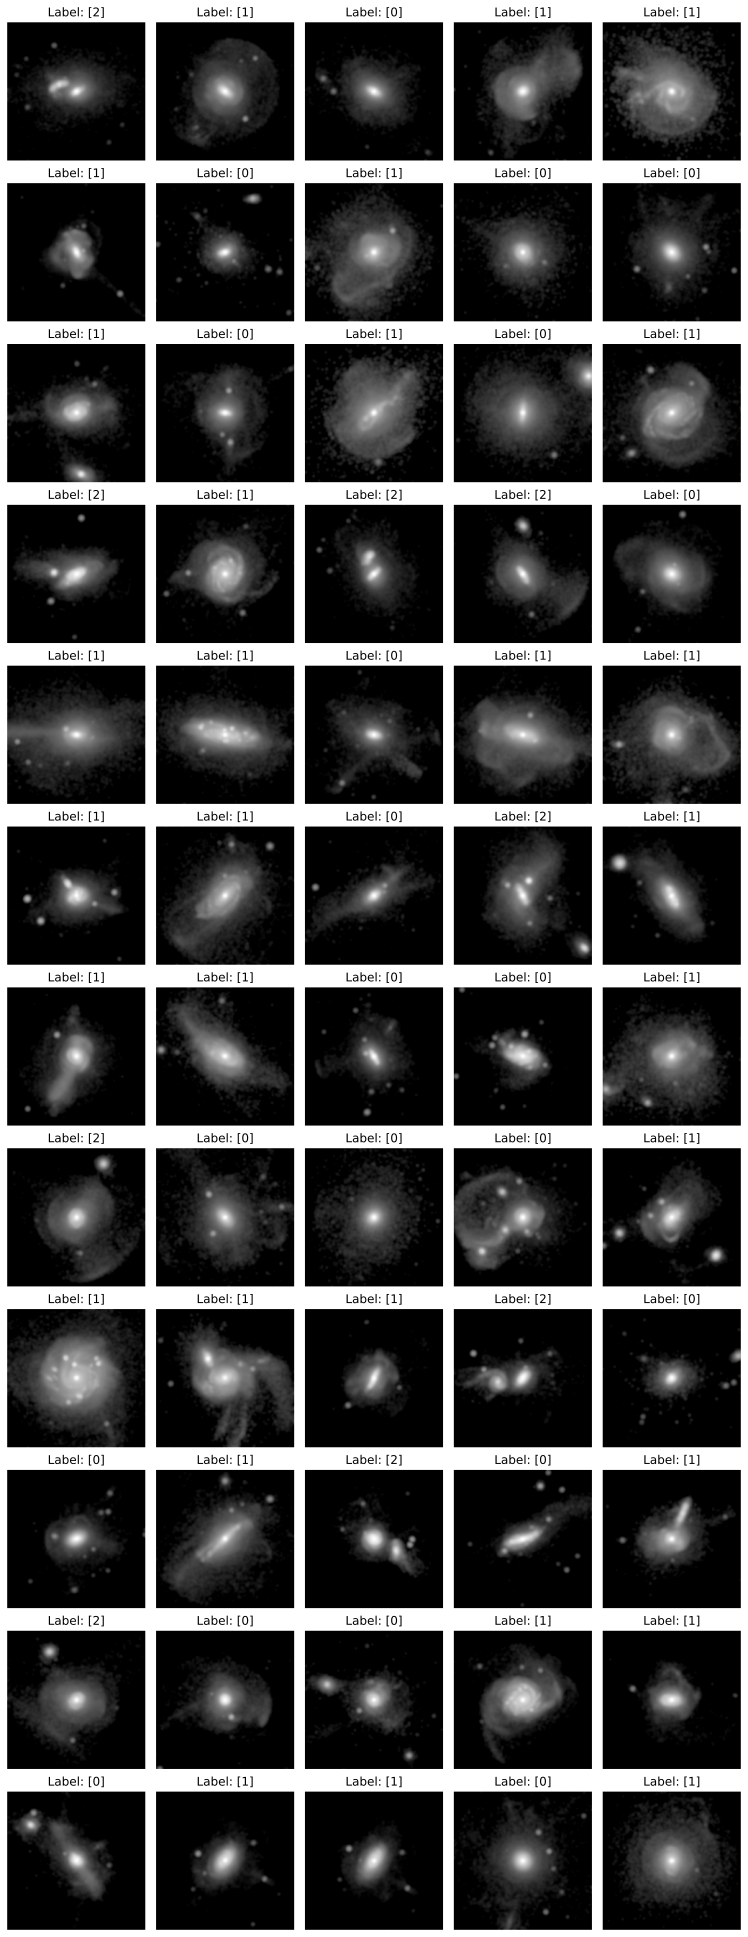

In [41]:
fig = plt.figure(figsize=(10.5, 27))

for i in range(60):
    ax = plt.subplot(12, 5, i + 1)
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title('Label: ' + str(y_train[i]))
    ax.axis('off')
    ax.set_aspect('equal')  # ✅ THIS is what ensures x/y scale = 1:1

plt.tight_layout()
plt.show()

## Loading Data as PyTorch Compatibles.. 

In [42]:
# Images: [N, 500, 500, 1] → [N, 1, 500, 500]  (PyTorch expects CHW)
x_train_tensor = torch.from_numpy(x_train).permute(0, 3, 1, 2)
x_val_tensor   = torch.from_numpy(x_val).permute(0, 3, 1, 2)
x_test_tensor  = torch.from_numpy(x_test).permute(0, 3, 1, 2)

# Labels: [N, 1] → [N]  (flatten)
y_train_tensor = torch.from_numpy(y_train).squeeze(1).long()
y_val_tensor   = torch.from_numpy(y_val).squeeze(1).long()
y_test_tensor  = torch.from_numpy(y_test).squeeze(1).long()

In [43]:
from torch.utils.data import TensorDataset

train_set = TensorDataset(x_train_tensor, y_train_tensor)
val_set   = TensorDataset(x_val_tensor, y_val_tensor)
test_set  = TensorDataset(x_test_tensor, y_test_tensor)

In [44]:
print(myBATCH_SIZE)

64


In [45]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_set, batch_size=myBATCH_SIZE, shuffle=True, drop_last=True, pin_memory=True, num_workers=0)
val_loader   = DataLoader(val_set, batch_size=myBATCH_SIZE, shuffle=False, drop_last=False, pin_memory=True, num_workers=0)
test_loader  = DataLoader(test_set, batch_size=myBATCH_SIZE, shuffle=False, drop_last=False, pin_memory=True, num_workers=0)

#### Visualize the torch training set 

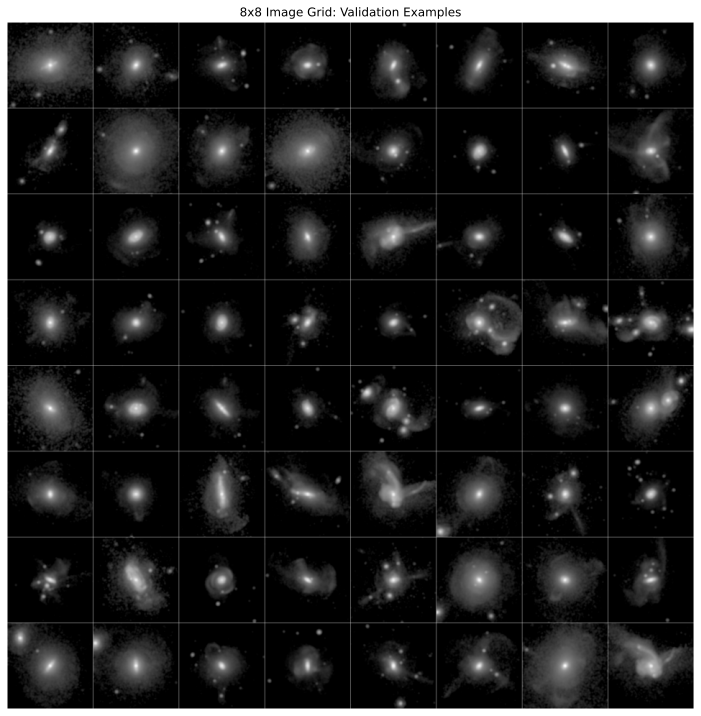

In [46]:
import matplotlib.pyplot as plt
import torchvision
import torch

# Parameters
ROWS = 8
COLS = 8
NUM_IMAGES = ROWS * COLS

# Stack selected images
CIFAR_images = torch.stack([val_set[idx][0] for idx in range(NUM_IMAGES)], dim=0)

# Create grid: nrow=COLS controls how many images per row
img_grid = torchvision.utils.make_grid(CIFAR_images, nrow=COLS, normalize=True, pad_value=0.9)
img_grid = img_grid.permute(1, 2, 0)  # Convert CHW to HWC for imshow

# Plotting
plt.figure(figsize=(COLS * 1.55, ROWS * 1.55))  # Scale figure size to number of images
plt.title(f"{ROWS}x{COLS} Image Grid: Validation Examples")
plt.imshow(img_grid)
plt.axis("off")
plt.show()
plt.close()

# Vision Transformer for image classification

#### Image Patches

> First, let’s implement the image preprocessing: an image of size $N \times N$ has to be <br>
> split into $(N/M)^2$ patches of size $M \times M$. These represent the input words to the Transformer.

- $N = 500$
- $M = 10$ ?!?

In [47]:
print(myIMLEN)

500


In [48]:
myPATCH_SIZE = [5, 10, 25, 50]

In [49]:
def img_to_patch(x, patch_size, flatten_channels=True):
    """
    Args:
        x: Tensor representing the image of shape [B, C, H, W]
        patch_size: Number of pixels per dimension of the patches (integer)
        flatten_channels: If True, the patches will be returned in a flattened format
                           as a feature vector instead of a image grid.
    """
    B, C, H, W = x.shape
    x = x.reshape(B, C, H // patch_size, patch_size, W // patch_size, patch_size)
    x = x.permute(0, 2, 4, 1, 3, 5)  # [B, H', W', C, p_H, p_W]
    x = x.flatten(1, 2)  # [B, H'*W', C, p_H, p_W]
    if flatten_channels:
        x = x.flatten(2, 4)  # [B, H'*W', C*p_H*p_W]
    return x

In [50]:
num_images = 64
patch_size = myPATCH_SIZE[3]

In [51]:
# Stack selected images
val_images = torch.stack([val_set[idx][0] for idx in range(num_images)], dim=0)

In [52]:
img_patches = img_to_patch(val_images, patch_size=patch_size, flatten_channels=False)

In [53]:
tmpnrow = myIMLEN // patch_size

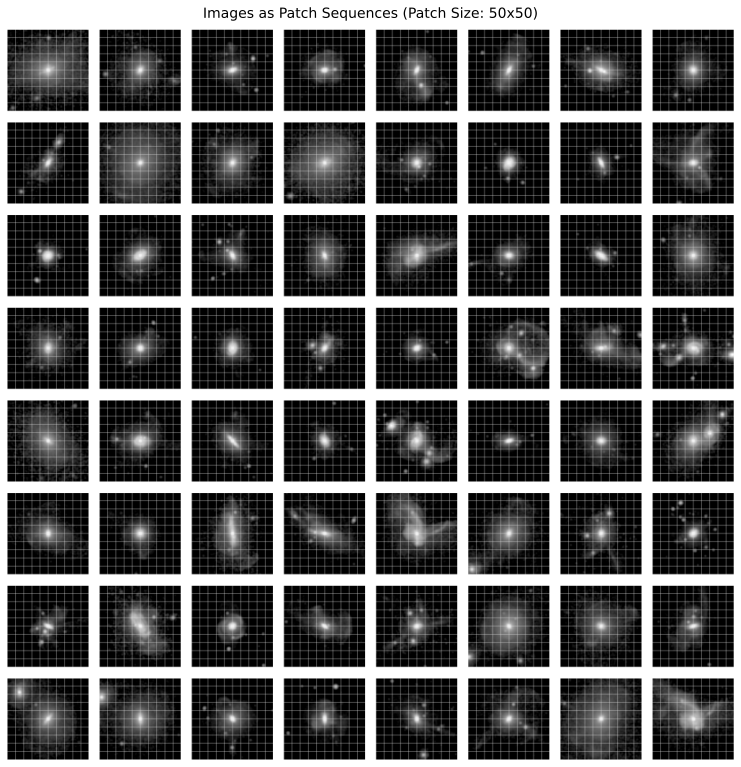

In [54]:
import math
import matplotlib.pyplot as plt
import torchvision

# Plot in 8 columns
COLS = 8
ROWS = math.ceil(num_images / COLS)

fig, axes = plt.subplots(ROWS, COLS, figsize=(COLS * 1.3, ROWS * 1.3))
fig.suptitle(f"Images as Patch Sequences (Patch Size: {patch_size}x{patch_size})", fontsize=14, y=1.02)

for i in range(num_images):
    row = i // COLS
    col = i % COLS
    ax = axes[row][col] if ROWS > 1 else axes[col]

    # Create patch grid image
    img_grid = torchvision.utils.make_grid(img_patches[i], nrow=tmpnrow, normalize=True, pad_value=0.9)
    img_grid = img_grid.permute(1, 2, 0)

    ax.imshow(img_grid)
    ax.axis("off")

# Hide any unused subplots
for i in range(num_images, ROWS * COLS):
    row = i // COLS
    col = i % COLS
    ax = axes[row][col] if ROWS > 1 else axes[col]
    ax.axis("off")

plt.tight_layout()
plt.subplots_adjust(top=0.99)  # Leave space for suptitle
plt.show()
plt.close()


#### Transformer Block with Pre-Layer Normalization 

In [55]:
class AttentionBlock(nn.Module):
    def __init__(self, embed_dim, hidden_dim, num_heads, dropout=0.0):
        super().__init__()
        self.layer_norm_1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=False)
        self.layer_norm_2 = nn.LayerNorm(embed_dim)
        self.linear = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout),
        )
        self.last_attn_weights = None  # 🆕 store attention weights here

    def forward(self, x):
        inp_x = self.layer_norm_1(x)
        #attn_out, attn_weights = self.attn(inp_x, inp_x, inp_x, need_weights=True)
        attn_out, attn_weights = self.attn(inp_x, inp_x, inp_x,need_weights=True, \
                                           average_attn_weights=False)  # 🧠 retain all heads!        
        self.last_attn_weights = attn_weights  # 🆕 save for inspection

        x = x + attn_out
        x = x + self.linear(self.layer_norm_2(x))
        return x

#### Wrapped-up Vision Transformer

In [56]:
class VisionTransformer(nn.Module):
    def __init__(
        self,
        embed_dim,
        hidden_dim,
        num_channels,
        num_heads,
        num_layers,
        num_classes,
        patch_size,
        num_patches,
        dropout=0.0,
    ):
        """Vision Transformer.

        Args:
            embed_dim: Dimensionality of the input feature vectors to the Transformer
            hidden_dim: Dimensionality of the hidden layer in the feed-forward networks
                         within the Transformer
            num_channels: Number of channels of the input (3 for RGB)
            num_heads: Number of heads to use in the Multi-Head Attention block
            num_layers: Number of layers to use in the Transformer
            num_classes: Number of classes to predict
            patch_size: Number of pixels that the patches have per dimension
            num_patches: Maximum number of patches an image can have
            dropout: Amount of dropout to apply in the feed-forward network and
                      on the input encoding

        """
        super().__init__()

        self.patch_size = patch_size

        # Layers/Networks
        self.input_layer = nn.Linear(num_channels * (patch_size**2), embed_dim)
        self.transformer = nn.Sequential(
            *(AttentionBlock(embed_dim, hidden_dim, num_heads, dropout=dropout) for _ in range(num_layers))
        )
        self.mlp_head = nn.Sequential(nn.LayerNorm(embed_dim), nn.Linear(embed_dim, num_classes))
        self.dropout = nn.Dropout(dropout)

        # Parameters/Embeddings
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embedding = nn.Parameter(torch.randn(1, 1 + num_patches, embed_dim))

    def forward(self, x):
        # Preprocess input
        x = img_to_patch(x, self.patch_size)
        B, T, _ = x.shape
        x = self.input_layer(x)

        # Add CLS token and positional encoding
        cls_token = self.cls_token.repeat(B, 1, 1)
        x = torch.cat([cls_token, x], dim=1)
        x = x + self.pos_embedding[:, : T + 1]

        # Apply Transforrmer
        x = self.dropout(x)
        x = x.transpose(0, 1)
        x = self.transformer(x)

        # Perform classification prediction
        cls = x[0]
        out = self.mlp_head(cls)
        return out

In [57]:
class ViT(pl.LightningModule):
    def __init__(self, model_kwargs, lr):
        super().__init__()
        self.save_hyperparameters()
        self.model = VisionTransformer(**model_kwargs)
        self.example_input_array = next(iter(train_loader))[0]

    def forward(self, x):
        return self.model(x)

    def configure_optimizers(self):
        optimizer = optim.AdamW(self.parameters(), lr=self.hparams.lr)
        lr_scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[100, 150], gamma=0.1)
        return [optimizer], [lr_scheduler]

    def _calculate_loss(self, batch, mode="train"):
        imgs, labels = batch
        preds = self.model(imgs)
        loss = F.cross_entropy(preds, labels)
        acc = (preds.argmax(dim=-1) == labels).float().mean()

        self.log(f"{mode}_loss", loss)
        self.log(f"{mode}_acc", acc)
        return loss

    def training_step(self, batch, batch_idx):
        loss = self._calculate_loss(batch, mode="train")
        return loss

    def validation_step(self, batch, batch_idx):
        self._calculate_loss(batch, mode="val")

    def test_step(self, batch, batch_idx):
        self._calculate_loss(batch, mode="test")

## Model Fits

In [58]:
import time
from pytorch_lightning.callbacks import Callback

class MetricTracker(Callback):
    def __init__(self, cooldown_every_n_epochs=5, cooldown_seconds=5):
        # Tracking metrics
        self.train_loss = []
        self.val_loss = []
        self.train_acc = []
        self.val_acc = []

        # Cooldown settings
        self.cooldown_every_n_epochs = cooldown_every_n_epochs
        self.cooldown_seconds = cooldown_seconds

    # ------------------------------
    # Metric collection
    # ------------------------------
    def on_validation_end(self, trainer, pl_module):
        # Skip sanity check validation
        if trainer.sanity_checking:
            return
            
        logs = trainer.callback_metrics

        val_loss = logs["val_loss"].item()
        val_acc = logs["val_acc"].item()

        self.val_loss.append(val_loss)
        self.val_acc.append(val_acc)

        current_epoch = trainer.current_epoch

        # ✅ Clean summary output
        print(f"✅ Epoch {current_epoch:03d} — val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}")

    def on_train_epoch_end(self, trainer, pl_module, unused=None):
        logs = trainer.callback_metrics

        if "train_loss" in logs and "train_acc" in logs:
            self.train_loss.append(logs["train_loss"].item())
            self.train_acc.append(logs["train_acc"].item())

        # 🧊 Cooldown logic
        current_epoch = trainer.current_epoch
        if self.cooldown_every_n_epochs and current_epoch > 0:
            if current_epoch % self.cooldown_every_n_epochs == 0:
                print("== 🔥 GPU Cooling Break 🔥 ==")
                print(f"🧊 Cooling down after epoch {current_epoch}... sleeping for {self.cooldown_seconds} seconds.")
                time.sleep(self.cooldown_seconds)

    # ------------------------------
    # Disable progress bars (completely) ; though this block is not working .. 
    # ------------------------------
    def on_fit_start(self, trainer, pl_module):
        trainer.enable_progress_bar = False

    def on_validation_epoch_start(self, trainer, pl_module):
        trainer.enable_progress_bar = False

    def on_validation_epoch_end(self, trainer, pl_module):
        trainer.enable_progress_bar = False  # Keep it off

In [59]:
from pytorch_lightning.loggers import CSVLogger

def train_model(**kwargs):
    #metric_tracker = MetricTracker()
    metric_tracker = MetricTracker(cooldown_every_n_epochs=5,cooldown_seconds=5)

    # Get user-defined checkpoints_dir or fallback to CHECKPOINT_PATH
    checkpoints_dir = kwargs.pop("mycheckpoints", CHECKPOINT_PATH)
    max_epochs = kwargs.pop("max_epochs", 180)  # 👈 default to 180 if not provided
    vit_dir = os.path.join(checkpoints_dir, "ViT")

    # Add a lightweight CSV logger
    logger = CSVLogger(save_dir=checkpoints_dir, name="ViT_logs")

    trainer = pl.Trainer(
        default_root_dir=vit_dir,
        accelerator="auto",
        devices=1,
        max_epochs=max_epochs,
        enable_progress_bar=False,  # ⛔ disables all tqdm bars including validation
        callbacks=[
            ModelCheckpoint(save_weights_only=True, mode="max", monitor="val_acc"),
            LearningRateMonitor("epoch"),
            metric_tracker,
        ],
        logger=logger,  # ✅ Now using CSVLogger
    )

    pretrained_filename = os.path.join(checkpoints_dir, "ViT.ckpt")
    if os.path.isfile(pretrained_filename):
        print(f"Found pretrained model at {pretrained_filename}, loading...")
        model = ViT.load_from_checkpoint(pretrained_filename)
    else:
        pl.seed_everything(42)
        model = ViT(**kwargs)
        trainer.fit(model, train_loader, val_loader)
        model = ViT.load_from_checkpoint(trainer.checkpoint_callback.best_model_path)

    # Temporarily disable progress bar for validation/test
    trainer.enable_progress_bar = False
    
    val_result = trainer.test(model, dataloaders=val_loader, verbose=False)
    test_result = trainer.test(model, dataloaders=test_loader, verbose=False)
    result = {"test": test_result[0]["test_acc"], "val": val_result[0]["test_acc"]}

    return model, result, metric_tracker

In [60]:
print(myPATCH_SIZE)
print(patch_size)

[5, 10, 25, 50]
50


In [61]:
# number of patches
(myIMLEN // patch_size)**2 

100

In [97]:
numpatchgrid = myIMLEN // patch_size

In [98]:
numpatches = (myIMLEN // patch_size)**2 

In [62]:
%%time
model, results, tracker = train_model(
    model_kwargs={
        "embed_dim": 256,
        "hidden_dim": 512,
        "num_heads": 8,
        "num_layers": 6,
        "patch_size": patch_size,
        "num_channels": 1,
        "num_patches": numpatches,
        "num_classes": 3,
        "dropout": 0.2,
    },
    lr=3e-4,
    max_epochs=100,
    #mycheckpoints=checkpoints_dir
)
print("ViT results", results)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Seed set to 42
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name  | Type              | Params | Mode  | In sizes          | Out sizes
------------------------------------------------------------------------------------
0 | model | VisionTransformer | 3.8 M  | train | [64, 1, 500, 500] | [64, 3]  
------------------------------------------------------------------------------------
3.8 M     Trainable params
0         Non-trainable params
3.8 M     Total params
15.321    Total estimated model params size (MB)
73

✅ Epoch 000 — val_loss: 0.9166 | val_acc: 0.5827
✅ Epoch 001 — val_loss: 1.0594 | val_acc: 0.5294
✅ Epoch 002 — val_loss: 0.8665 | val_acc: 0.6232
✅ Epoch 003 — val_loss: 1.1191 | val_acc: 0.5294
✅ Epoch 004 — val_loss: 0.7353 | val_acc: 0.7040
✅ Epoch 005 — val_loss: 0.7881 | val_acc: 0.6507
== 🔥 GPU Cooling Break 🔥 ==
🧊 Cooling down after epoch 5... sleeping for 5 seconds.
✅ Epoch 006 — val_loss: 0.8818 | val_acc: 0.6158
✅ Epoch 007 — val_loss: 0.7265 | val_acc: 0.7224
✅ Epoch 008 — val_loss: 0.7813 | val_acc: 0.6746
✅ Epoch 009 — val_loss: 0.6624 | val_acc: 0.7206
✅ Epoch 010 — val_loss: 0.6762 | val_acc: 0.7316
== 🔥 GPU Cooling Break 🔥 ==
🧊 Cooling down after epoch 10... sleeping for 5 seconds.
✅ Epoch 011 — val_loss: 0.6755 | val_acc: 0.7316
✅ Epoch 012 — val_loss: 0.6627 | val_acc: 0.7279
✅ Epoch 013 — val_loss: 0.8228 | val_acc: 0.6415
✅ Epoch 014 — val_loss: 0.6356 | val_acc: 0.7574
✅ Epoch 015 — val_loss: 0.6174 | val_acc: 0.7610
== 🔥 GPU Cooling Break 🔥 ==
🧊 Cooling down afte

`Trainer.fit` stopped: `max_epochs=100` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


✅ Epoch 099 — val_loss: 0.9842 | val_acc: 0.8033


/usr/local/lib/python3.10/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


ViT results {'test': 0.8367646932601929, 'val': 0.8363970518112183}
CPU times: user 7min 40s, sys: 3min 35s, total: 11min 15s
Wall time: 4min 23s


In [63]:
print("ViT results", results)

ViT results {'test': 0.8367646932601929, 'val': 0.8363970518112183}


In [64]:
print("ViT results", tracker)
print(f"Train Loss: {len(tracker.train_loss)}")
print(f"Val Loss:   {len(tracker.val_loss)}")

ViT results <__main__.MetricTracker object at 0x7fb9ae0d3be0>
Train Loss: 100
Val Loss:   100


In [65]:
import matplotlib.pyplot as plt
import matplotlib

def plot_metrics(metrics):
    # 🖋️ Set global font settings
    matplotlib.rcParams["font.family"] = "serif"
    matplotlib.rcParams["mathtext.fontset"] = "stix"

    # Gather metric lengths
    train_len = len(metrics.train_loss)
    val_len = len(metrics.val_loss)
    min_len = min(train_len, val_len)

    if min_len == 0:
        print("⚠️ No metric data to plot.")
        return

    # Create matching epoch indices
    epochs = list(range(1, min_len + 1))

    # Slice to sync lengths
    train_loss = metrics.train_loss[:min_len]
    val_loss = metrics.val_loss[:min_len]
    train_acc = metrics.train_acc[:min_len]
    val_acc = metrics.val_acc[:min_len]

    # Check for flat data
    def is_constant(data):
        return all(x == data[0] for x in data)

    # Begin plotting
    plt.figure(figsize=(9, 4))

    # 🔹 Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label='Train Loss', marker='o')
    plt.plot(epochs, val_loss, label='Val Loss', marker='x')
    plt.title("Loss over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    if is_constant(train_loss + val_loss):
        print("⚠️ Loss values are constant — check your training loop.")

    # 🔸 Accuracy Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label='Train Acc', marker='o')
    plt.plot(epochs, val_acc, label='Val Acc', marker='x')
    plt.title("Accuracy over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    if is_constant(train_acc + val_acc):
        print("⚠️ Accuracy values are constant — check your logging or model performance.")

    plt.tight_layout()
    plt.show()

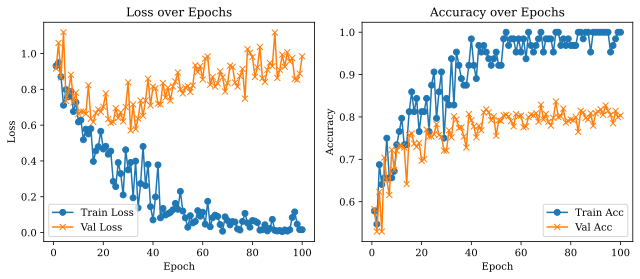

In [66]:
plot_metrics(tracker)

## Predictions and Performance Evaluations

#### Where the output log is 

In [67]:
resultsroot = CHECKPOINT_PATH+'/ViT_logs/'
print(resultsroot)

/app/vistf/merger-clf/checkpoints/merger-clf-take1/ViT_logs/


In [68]:
resultsdir = !ls {resultsroot}
print(resultsdir)

['version_0']


In [69]:
%ls {resultsroot+resultsdir[0]}

checkpoints/  hparams.yaml  metrics.csv


In [70]:
modelname = !ls {resultsroot+resultsdir[0]+'/checkpoints/'}
print(modelname)

['epoch=73-step=2442.ckpt']


In [71]:
resultsroot+resultsdir[0]+'/checkpoints/'+modelname[0]

'/app/vistf/merger-clf/checkpoints/merger-clf-take1/ViT_logs/version_0/checkpoints/epoch=73-step=2442.ckpt'

## Predictions

In [72]:
import torch

def predict(model, dataloader, device="cuda" if torch.cuda.is_available() else "cpu"):
    model.eval()
    model.to(device)

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            logits = model(x)
            preds = torch.argmax(logits, dim=1)

            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())

    # Concatenate all batches into single tensors
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    return all_preds, all_labels

In [73]:
preds, labels = predict(model, test_loader)

In [74]:
len(preds)

680

In [76]:
# Example: show 10 predictions
print("Predicted   :", preds[600:630].tolist())
print("Ground truth:", labels[600:630].tolist())

Predicted   : [0, 1, 1, 1, 0, 2, 1, 0, 2, 0, 1, 1, 0, 1, 1, 1, 1, 2, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1]
Ground truth: [0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 2, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1]


In [77]:
import torch
import torch.nn.functional as F

def predict_prob(model, dataloader, device="cuda" if torch.cuda.is_available() else "cpu"):
    model.eval()
    model.to(device)

    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            logits = model(x)

            probs = F.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_preds.append(preds.cpu())
            all_probs.append(probs.cpu())
            all_labels.append(y.cpu())

    # Concatenate all batches
    all_preds = torch.cat(all_preds)
    all_probs = torch.cat(all_probs)
    all_labels = torch.cat(all_labels)

    return all_preds, all_probs, all_labels

In [78]:
preds, probs, labels = predict_prob(model, test_loader)

In [79]:
print("Preds: ", preds[:3].tolist())
print("Labels:", labels[:3].tolist())
print("Probs: ", probs[:3].tolist())  # shape: [5, num_classes]

Preds:  [1, 1, 1]
Labels: [0, 0, 1]
Probs:  [[0.011822382919490337, 0.9881640672683716, 1.3488648619386367e-05], [0.10445615649223328, 0.8953732848167419, 0.0001705499889794737], [0.008711234666407108, 0.9901212453842163, 0.0011675477726384997]]


## Confusion Matrix

In [80]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [92]:
def plot_confusion_matrix(preds, labels, class_names=None, normalize=True):
    cm = confusion_matrix(labels, preds)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d",
                cmap="Blues", xticklabels=class_names, yticklabels=class_names)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix" + (" (Normalized)" if normalize else ""))
    plt.tight_layout()
    plt.savefig('ViT-Merger-Confusion-Matrix.png', dpi=100)
    plt.show()

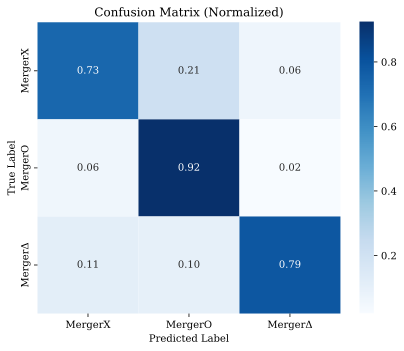

In [93]:
class_names = [
    'MergerX','MergerO','MergerΔ'
]

plot_confusion_matrix(preds, labels, class_names=class_names)

## Attention Map

#### Test Images

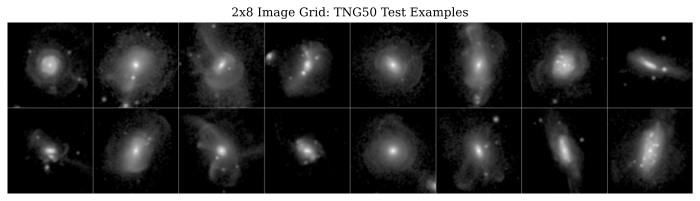

In [114]:
import matplotlib.pyplot as plt
import torchvision
import torch

# Parameters
ROWS = 2
COLS = 8
NUM_IMAGES = ROWS * COLS

# Stack selected images
test_images = torch.stack([test_set[idx][0] for idx in range(NUM_IMAGES)], dim=0)

# Create grid: nrow=COLS controls how many images per row
img_grid = torchvision.utils.make_grid(test_images, nrow=COLS, normalize=True, pad_value=0.9)
img_grid = img_grid.permute(1, 2, 0)  # Convert CHW to HWC for imshow

# Plotting
plt.figure(figsize=(COLS * 1.55, ROWS * 1.55))  # Scale figure size to number of images
plt.title("2x8 Image Grid: TNG50 Test Examples")
plt.imshow(img_grid)
plt.axis("off")
plt.show()
plt.close()

#### Attention Map

In [99]:
print(numpatchgrid)

10


In [100]:
def get_last_attn_map(model: VisionTransformer, x: torch.Tensor, patch_grid=(10, 10)) -> np.ndarray:
    """
    Extract the last CLS-to-patch attention map as a 2D NumPy array.
    Args:
        model: VisionTransformer instance
        x: image tensor [1, 3, H, W]
        patch_grid: expected (H', W') shape of the attention map

    Returns:
        np.ndarray: attention heatmap [H', W']
    """
    model.eval()
    with torch.no_grad():
        _ = model(x)  # run forward to populate attention

        # Fetch stored attention from final transformer block
        attn = model.transformer[-1].last_attn_weights  # [1, num_heads, tokens, tokens]
        attn_cls = attn.mean(dim=1)[:, 0, 1:]  # [1, num_patches]

        attn_2d = attn_cls.reshape(*patch_grid)
        return attn_2d.cpu().numpy()

In [101]:
img_tensor = test_set[0][0].unsqueeze(0).to(device)
attn_map_np = get_last_attn_map(model.model, img_tensor, patch_grid=(10, 10))

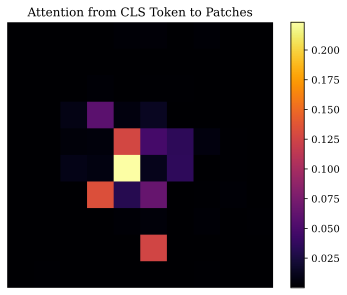

In [102]:
import matplotlib.pyplot as plt
plt.imshow(attn_map_np, cmap="inferno")
plt.colorbar()
plt.title("Attention from CLS Token to Patches")
plt.axis("off")
plt.show()

#### All in one Images 

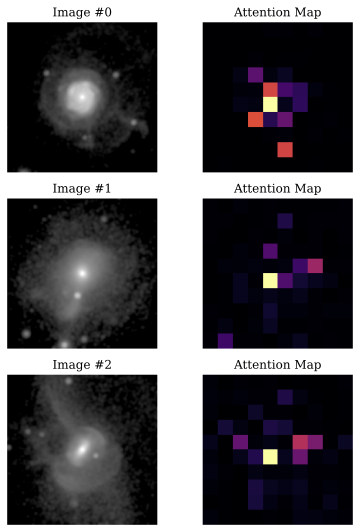

In [106]:
import matplotlib.pyplot as plt
import torch

# Plotting 3 test images + attention maps
NUM_ROWS = 3
plt.figure(figsize=(6, NUM_ROWS * 2.5))

for i in range(NUM_ROWS):
    img_tensor = test_set[i][0]  # [1, H, W] or [3, H, W] depending on your data
    img_batch = img_tensor.unsqueeze(0).to(device)  # [1, C, H, W]

    # Get attention map
    attn_map_np = get_last_attn_map(model.model, img_batch, patch_grid=(10, 10))

    # --- Plot original image (left column) ---
    plt.subplot(NUM_ROWS, 2, i * 2 + 1)
    img_vis = img_tensor.permute(1, 2, 0).cpu().numpy()  # [H, W, C]
    plt.imshow(img_vis,cmap="gray", interpolation="nearest")
    plt.title(f"Image #{i}")
    plt.axis("off")

    # --- Plot attention map (right column) ---
    plt.subplot(NUM_ROWS, 2, i * 2 + 2)
    plt.imshow(attn_map_np, cmap="inferno", interpolation="nearest")
    plt.title("Attention Map")
    plt.axis("off")

plt.tight_layout()
plt.show()


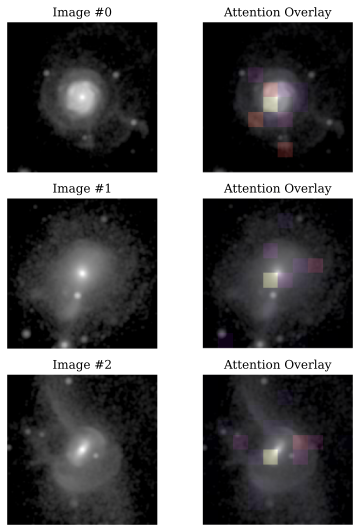

In [110]:
import matplotlib.pyplot as plt
import torch

NUM_ROWS = 3
plt.figure(figsize=(6, NUM_ROWS * 2.5))

for i in range(NUM_ROWS):
    img_tensor = test_set[i][0]  # shape: [1, H, W]
    img_batch = img_tensor.unsqueeze(0).to(device)  # [1, 1, H, W]

    # Get attention map
    attn_map_np = get_last_attn_map(model.model, img_batch, patch_grid=(10, 10))

    # Prepare image: convert to 2D numpy array
    img_vis = img_tensor.squeeze(0).cpu().numpy()  # shape: [H, W]

    # --- Left: original grayscale image ---
    plt.subplot(NUM_ROWS, 2, i * 2 + 1)
    plt.imshow(img_vis, cmap="gray", interpolation="nearest")
    plt.title(f"Image #{i}")
    plt.axis("off")

    # --- Right: overlay attention on grayscale image ---
    plt.subplot(NUM_ROWS, 2, i * 2 + 2)
    plt.imshow(img_vis, cmap="gray", interpolation="nearest")  # background
    plt.imshow(attn_map_np, cmap="inferno", alpha=0.5, interpolation="nearest", extent=[0, img_vis.shape[1], img_vis.shape[0], 0])  # overlay
    plt.title("Attention Overlay")
    plt.axis("off")

plt.tight_layout()
plt.savefig('ViT-Merger-Attention-Map.png', dpi=300)
plt.show()

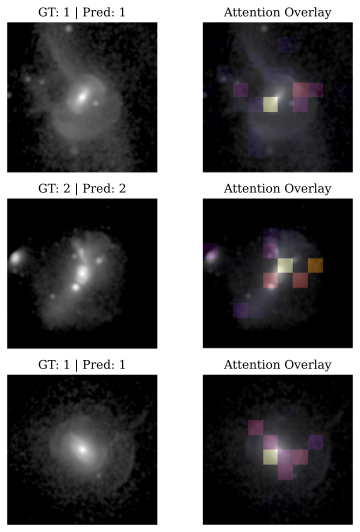

In [113]:
import matplotlib.pyplot as plt
import torch

NUM_ROWS = 3
plt.figure(figsize=(6, NUM_ROWS * 2.5))

ioffset = 2

for i in range(NUM_ROWS):
    img_tensor, true_label = test_set[i+ioffset]  # Unpack image + label
    img_batch = img_tensor.unsqueeze(0).to(device)  # [1, 1, H, W]

    # Get prediction
    with torch.no_grad():
        pred_logits = model(img_batch)
        pred_label = pred_logits.argmax(dim=1).item()

    # Get attention map
    attn_map_np = get_last_attn_map(model.model, img_batch, patch_grid=(10, 10))

    # Prepare grayscale image
    img_vis = img_tensor.squeeze(0).cpu().numpy()

    # --- Left: original grayscale image ---
    plt.subplot(NUM_ROWS, 2, i * 2 + 1)
    plt.imshow(img_vis, cmap="gray", interpolation="nearest")
    plt.title(f"GT: {true_label} | Pred: {pred_label}")
    plt.axis("off")

    # --- Right: overlay attention ---
    plt.subplot(NUM_ROWS, 2, i * 2 + 2)
    plt.imshow(img_vis, cmap="gray", interpolation="nearest")
    plt.imshow(attn_map_np, cmap="inferno", alpha=0.6, interpolation="nearest", extent=[0, img_vis.shape[1], img_vis.shape[0], 0])
    plt.title("Attention Overlay")
    plt.axis("off")

plt.tight_layout()
plt.savefig('ViT-Merger-Attention-Map.png', dpi=300)
plt.show()